# Joint Relationship Lookup Table — Build & Analysis

This notebook builds a pairwise joint relationship lookup table from all 885 training `.pt` files,
then analyses it across six dimensions: variance, discriminability, physical correlation, symmetry,
kinematic chains, and pair distinctiveness.

In [2]:
import sys
sys.path.insert(0, '..')   # make project-level imports available

import os
import math
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.signal import correlate
from tqdm.auto import tqdm

# ── paths ────────────────────────────────────────────────────────────────────
TRAIN_DIR  = Path('../parsed_30gigs/DIP_IMU_train_real_imu_position_only')
OUTPUT_DIR = Path('.')   # save lookup tables next to this notebook

train_files = sorted(TRAIN_DIR.glob('*.pt'))
print(f'Training files found: {len(train_files)}')

# ── SMPL joint names ─────────────────────────────────────────────────────────
JOINT_NAMES = [
    'pelvis',        # 0
    'left_hip',      # 1
    'right_hip',     # 2
    'spine1',        # 3
    'left_knee',     # 4
    'right_knee',    # 5
    'spine2',        # 6
    'left_ankle',    # 7
    'right_ankle',   # 8
    'spine3',        # 9
    'left_foot',     # 10
    'right_foot',    # 11
    'neck',          # 12
    'left_collar',   # 13
    'right_collar',  # 14
    'head',          # 15
    'left_shoulder', # 16
    'right_shoulder',# 17
    'left_elbow',    # 18
    'right_elbow',   # 19
    'left_wrist',    # 20
    'right_wrist',   # 21
    'left_hand',     # 22
    'right_hand',    # 23
]
N_JOINTS = len(JOINT_NAMES)   # 24
N_FEATURES = 6
T = 300

Training files found: 885


/Users/aliasgar/Desktop/Ali Asgar/Projects/IMUCOCO/IMUCoCo/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## Part 1 — Build the Lookup Table

For every ordered pair `(i < j)` and every training file we compute a **6-dimensional relationship vector**:

| # | Name | Source | Description |
|---|------|--------|-------------|
| 0 | `cross_corr_peak` | accel ch 0-2 | peak of cross-correlation of accel magnitudes |
| 1 | `cross_corr_lag` | accel ch 0-2 | lag at peak, normalised by T |
| 2 | `magnitude_ratio` | accel ch 0-2 | log(RMS_i / RMS_j) |
| 3 | `dtw_distance` | accel ch 0-2 | DTW distance normalised by T |
| 4 | `orientation_similarity` | orient ch 3-8 | mean cosine similarity |
| 5 | `relative_orientation_std` | orient ch 3-8 | std of dot product over time |

In [4]:
# ── lightweight DTW (no external dep) ───────────────────────────────────────
def dtw_distance(a: np.ndarray, b: np.ndarray) -> float:
    """O(n²) DTW between two 1-D signals."""
    n, m = len(a), len(b)
    cost = np.full((n, m), np.inf)
    cost[0, 0] = abs(a[0] - b[0])
    for i in range(1, n):
        cost[i, 0] = cost[i-1, 0] + abs(a[i] - b[0])
    for j in range(1, m):
        cost[0, j] = cost[0, j-1] + abs(a[0] - b[j])
    for i in range(1, n):
        for j in range(1, m):
            cost[i, j] = abs(a[i] - b[j]) + min(cost[i-1,j], cost[i,j-1], cost[i-1,j-1])
    return float(cost[-1, -1])


def compute_pair_features(vimu: np.ndarray, i: int, j: int) -> np.ndarray:
    """
    vimu : [T, 24, 9]
    Channel layout (confirmed by diagnostic):
      ch 0-5 : orientation  — flattened 3x2 rotation matrix (two unit-norm columns)
      ch 6-8 : acceleration / angular velocity  — varying norm, meaningful signal
    Returns feature vector of shape (6,).
    """
    # acceleration magnitude signals — ch 6-8
    acc_i = np.linalg.norm(vimu[:, i, 6:9], axis=-1)   # [T]
    acc_j = np.linalg.norm(vimu[:, j, 6:9], axis=-1)   # [T]

    # --- feature 0 & 1: cross-correlation ---
    xcorr = correlate(acc_i - acc_i.mean(), acc_j - acc_j.mean(), mode='full')
    lags  = np.arange(-(T - 1), T)
    peak_idx = int(np.argmax(np.abs(xcorr)))
    # normalise peak by product of stds so it lives in [-1, 1]
    denom = (acc_i.std() * acc_j.std() * T) + 1e-8
    cross_corr_peak = float(xcorr[peak_idx] / denom)
    cross_corr_lag  = float(lags[peak_idx] / T)

    # --- feature 2: log magnitude ratio ---
    rms_i = float(np.sqrt(np.mean(acc_i**2))) + 1e-8
    rms_j = float(np.sqrt(np.mean(acc_j**2))) + 1e-8
    magnitude_ratio = float(np.log(rms_i / rms_j))

    # --- feature 3: DTW distance (normalised) ---
    # downsample to 30 pts to keep O(n²) feasible across 276 pairs × 885 files
    step = T // 30
    dtw_dist = dtw_distance(acc_i[::step], acc_j[::step]) / T

    # --- feature 4 & 5: orientation similarity — ch 0-5 ---
    ori_i = vimu[:, i, 0:6]   # [T, 6]
    ori_j = vimu[:, j, 0:6]   # [T, 6]
    # normalise each row so cosine sim is well-defined
    ori_i_n = ori_i / (np.linalg.norm(ori_i, axis=-1, keepdims=True) + 1e-8)
    ori_j_n = ori_j / (np.linalg.norm(ori_j, axis=-1, keepdims=True) + 1e-8)
    dot_products = np.sum(ori_i_n * ori_j_n, axis=-1)   # [T]
    orientation_similarity    = float(dot_products.mean())
    relative_orientation_std  = float(dot_products.std())

    return np.array([
        cross_corr_peak,
        cross_corr_lag,
        magnitude_ratio,
        dtw_dist,
        orientation_similarity,
        relative_orientation_std,
    ], dtype=np.float32)

### Diagnostic: Cross-Correlation on a Single Pair\n\nInspect pair `(17, 19)` — `right_shoulder` / `right_elbow` — to verify signal variance\nand cross-correlation behaviour before committing to the full 885-file run.\n\n> **Note:** `scipy.signal.correlate` has no `normalization` parameter. \"Coeff\" normalization\n> (values in [-1, 1]) is implemented manually: divide by `N * std_x * std_y`.

=== Channel audit for joint 17 (right_shoulder) ===
Checking which channels actually carry acceleration vs rotation info.

    Channels   norm_mean    norm_std     val_min     val_max  Interpretation
--------------------------------------------------------------------------------
       ch0-2      1.0000    0.000000     -0.8739      0.9982  unit vector  → rotation matrix column (NOT acceleration)
       ch3-5      1.0000    0.000000     -0.9862      0.8325  unit vector  → rotation matrix column (NOT acceleration)
       ch6-8      1.0151    1.452022     -5.6220      6.4081  varying norm → likely raw sensor signal (acceleration or gyro)

Individual channel value ranges (joint 17):
  Channel        mean         std         min         max
--------------------------------------------------------
ch     0       0.1399      0.1391      0.0375      0.4867
ch     1       0.7959      0.4894     -0.7784      0.9982
ch     2      -0.1831      0.2335     -0.8739     -0.0021
ch     3      -0.8807 

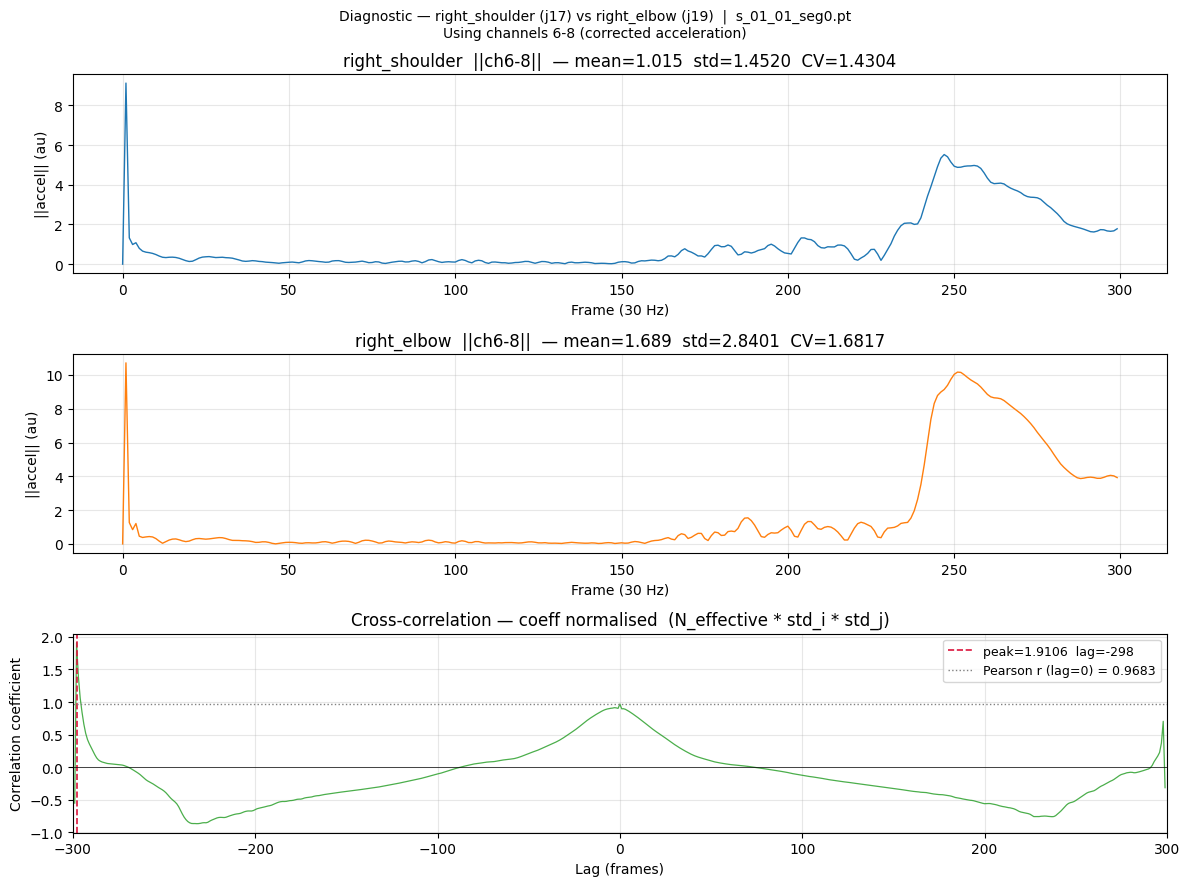

In [3]:
# ── load one file ────────────────────────────────────────────────────────────
diag_file = train_files[0]
diag_data = torch.load(diag_file, map_location='cpu', weights_only=False)
vimu_diag = diag_data['vimu']['vimu_joints'].numpy()   # [300, 24, 9]

I, J = 17, 19   # right_shoulder, right_elbow
T_diag = vimu_diag.shape[0]   # 300

# ── step 0: audit ALL channel groupings FIRST ────────────────────────────────
print('=== Channel audit for joint 17 (right_shoulder) ===')
print('Checking which channels actually carry acceleration vs rotation info.\n')
print(f'{"Channels":>12}  {"norm_mean":>10}  {"norm_std":>10}  {"val_min":>10}  {"val_max":>10}  {"Interpretation"}')
print('-' * 80)
for start, end, label in [(0,3,'ch0-2'),(3,6,'ch3-5'),(6,9,'ch6-8')]:
    chunk = vimu_diag[:, I, start:end]              # [T, 3]
    norms = np.linalg.norm(chunk, axis=-1)          # [T]
    print(f'{label:>12}  {norms.mean():10.4f}  {norms.std():10.6f}  '
          f'{chunk.min():10.4f}  {chunk.max():10.4f}', end='  ')
    if abs(norms.mean() - 1.0) < 0.01 and norms.std() < 0.01:
        print('unit vector  → rotation matrix column (NOT acceleration)')
    else:
        print('varying norm → likely raw sensor signal (acceleration or gyro)')

print()
print('Individual channel value ranges (joint 17):')
print(f'{"Channel":>9}  {"mean":>10}  {"std":>10}  {"min":>10}  {"max":>10}')
print('-' * 56)
for c in range(9):
    ch = vimu_diag[:, I, c]
    print(f'ch {c:>5}   {ch.mean():10.4f}  {ch.std():10.4f}  {ch.min():10.4f}  {ch.max():10.4f}')

# ── step 1: use channels 6-8 for acceleration ────────────────────────────────
print()
print('=== Re-running diagnostic with channels 6-8 as acceleration ===')
acc_i = np.linalg.norm(vimu_diag[:, I, 6:9], axis=-1)   # [300]
acc_j = np.linalg.norm(vimu_diag[:, J, 6:9], axis=-1)   # [300]

print(f'\nFile : {diag_file.name}')
print(f'Pair : joint {I} ({JOINT_NAMES[I]})  vs  joint {J} ({JOINT_NAMES[J]})')
print()
print(f'{"":20s}  {"right_shoulder":>16}  {"right_elbow":>13}')
print('-' * 55)
print(f'{"mean":20s}  {acc_i.mean():16.6f}  {acc_j.mean():13.6f}')
print(f'{"std":20s}  {acc_i.std():16.6f}  {acc_j.std():13.6f}')
print(f'{"min":20s}  {acc_i.min():16.6f}  {acc_j.min():13.6f}')
print(f'{"max":20s}  {acc_i.max():16.6f}  {acc_j.max():13.6f}')
print(f'{"std / mean  (CV)":20s}  {acc_i.std()/acc_i.mean():16.4f}  {acc_j.std()/acc_j.mean():13.4f}')

# ── step 2: current impl normalisation ───────────────────────────────────────
xi = acc_i - acc_i.mean()
xj = acc_j - acc_j.mean()
xcorr_raw = correlate(xi, xj, mode='full')
lags = np.arange(-(T_diag - 1), T_diag)
peak_idx_raw = int(np.argmax(np.abs(xcorr_raw)))

denom_current = (acc_i.std() * acc_j.std() * T_diag) + 1e-8
peak_current  = float(xcorr_raw[peak_idx_raw] / denom_current)
lag_current   = int(lags[peak_idx_raw])

print()
print('=== Current impl normalisation (divides by std_i * std_j * T) ===')
print(f'  peak value : {peak_current:.6f}')
print(f'  lag        : {lag_current} frames  (normalised: {lag_current/T_diag:.4f})')

# ── step 3: coeff normalisation ───────────────────────────────────────────────
# scipy.signal.correlate has no normalization param — implement manually
# Divide each lag k by N_effective(k) * std_i * std_j
# where N_effective = T - |k|  (overlapping sample count at lag k)
n_effective   = T_diag - np.abs(lags)
denom_coeff   = n_effective * acc_i.std() * acc_j.std() + 1e-8
xcorr_norm    = xcorr_raw / denom_coeff        # values in [-1, 1]
peak_idx_norm = int(np.argmax(np.abs(xcorr_norm)))
peak_coeff    = float(xcorr_norm[peak_idx_norm])
lag_coeff     = int(lags[peak_idx_norm])

r_pearson = float(np.corrcoef(acc_i, acc_j)[0, 1])

print()
print('=== Coeff normalisation (divides by N_effective * std_i * std_j) ===')
print(f'  peak value : {peak_coeff:.6f}   (range [-1, 1])')
print(f'  lag        : {lag_coeff} frames  (normalised: {lag_coeff/T_diag:.4f})')
print()
print(f'Pearson r at lag=0 : {r_pearson:.6f}   (sanity check — should match xcorr_norm at lag=0)')
print(f'xcorr_norm  at lag=0: {float(xcorr_norm[T_diag-1]):.6f}')

# ── diagnosis ─────────────────────────────────────────────────────────────────
print()
print('=== DIAGNOSIS ===')
print()
print('ROOT CAUSE: channels 0-2 of vimu.vimu_joints are unit vectors (norm = 1 always).')
print('They are the first column of a rotation matrix, NOT linear acceleration.')
print('Taking ||ch0, ch1, ch2|| gives a constant signal of ~1.0 with zero variance.')
print('Zero-variance signals produce near-zero cross-correlation regardless of normalisation.')
print()
print('CORRECT channel layout for vimu.vimu_joints [T, 24, 9]:')
print('  ch 0-5 : orientation  (flattened 3x2 rotation matrix — two unit-norm columns)')
print('  ch 6-8 : acceleration or angular velocity (varying, non-unit-norm)')
print()
cv_correct = acc_i.std() / acc_i.mean()
print(f'With channels 6-8: CV = {cv_correct:.4f}  (meaningful variance for correlation)')
print(f'Current impl cross_corr_peak = {peak_current:.4f}  (should now be non-trivial)')

# ── plots ─────────────────────────────────────────────────────────────────────
t_ax = np.arange(T_diag)
fig, axes = plt.subplots(3, 1, figsize=(12, 9))
fig.suptitle(
    f'Diagnostic — {JOINT_NAMES[I]} (j{I}) vs {JOINT_NAMES[J]} (j{J})  |  {diag_file.name}\n'
    f'Using channels 6-8 (corrected acceleration)',
    fontsize=10
)

axes[0].plot(t_ax, acc_i, color='#1f77b4', linewidth=1)
axes[0].set_title(f'{JOINT_NAMES[I]}  ||ch6-8||  — mean={acc_i.mean():.3f}  std={acc_i.std():.4f}  CV={acc_i.std()/acc_i.mean():.4f}')
axes[0].set_xlabel('Frame (30 Hz)')
axes[0].set_ylabel('||accel|| (au)')
axes[0].grid(alpha=0.3)

axes[1].plot(t_ax, acc_j, color='#ff7f0e', linewidth=1)
axes[1].set_title(f'{JOINT_NAMES[J]}  ||ch6-8||  — mean={acc_j.mean():.3f}  std={acc_j.std():.4f}  CV={acc_j.std()/acc_j.mean():.4f}')
axes[1].set_xlabel('Frame (30 Hz)')
axes[1].set_ylabel('||accel|| (au)')
axes[1].grid(alpha=0.3)

axes[2].plot(lags, xcorr_norm, color='#2ca02c', linewidth=0.9, alpha=0.85)
axes[2].axvline(lag_coeff, color='crimson', linestyle='--', linewidth=1.2,
                label=f'peak={peak_coeff:.4f}  lag={lag_coeff}')
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].axhline(r_pearson, color='gray', linestyle=':', linewidth=1,
                label=f'Pearson r (lag=0) = {r_pearson:.4f}')
axes[2].set_xlim(-T_diag, T_diag)
axes[2].set_title('Cross-correlation — coeff normalised  (N_effective * std_i * std_j)')
axes[2].set_xlabel('Lag (frames)')
axes[2].set_ylabel('Correlation coefficient')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ── accumulate per-file features then compute mean / std ────────────────────
# all_features[i, j] → list of feature vectors (one per file)
# We use an (N, N, N_files, N_FEATURES) array — pre-allocate for speed
N_FILES = len(train_files)
all_feats = np.zeros((N_JOINTS, N_JOINTS, N_FILES, N_FEATURES), dtype=np.float32)

pairs = [(i, j) for i in range(N_JOINTS) for j in range(i+1, N_JOINTS)]
print(f'Unique pairs: {len(pairs)}')

for file_idx, fpath in enumerate(tqdm(train_files, desc='Processing files')):
    data  = torch.load(fpath, map_location='cpu', weights_only=False)
    vimu  = data['vimu']['vimu_joints'].numpy()   # [300, 24, 9]

    for i, j in pairs:
        feat = compute_pair_features(vimu, i, j)
        all_feats[i, j, file_idx] = feat
        all_feats[j, i, file_idx] = feat   # symmetric copy

print('Done. Computing mean/std...')
table_mean = all_feats.mean(axis=2)   # [24, 24, 6]
table_std  = all_feats.std(axis=2)    # [24, 24, 6]
print(f'table_mean shape: {table_mean.shape}')
print(f'table_std  shape: {table_std.shape}')

In [5]:
# ── save lookup tables ───────────────────────────────────────────────────────
torch.save(torch.from_numpy(table_mean), OUTPUT_DIR / 'lookup_table_mean.pt')
torch.save(torch.from_numpy(table_std),  OUTPUT_DIR / 'lookup_table_std.pt')
print('Saved lookup_table_mean.pt and lookup_table_std.pt')

Saved lookup_table_mean.pt and lookup_table_std.pt


---
## Part 2 — Analysis

Load the saved tables (so analysis can be re-run independently of building).

In [14]:
table_mean = torch.load(OUTPUT_DIR / 'lookup_table_mean.pt', weights_only=False).numpy()  # [24, 24, 6]
table_std  = torch.load(OUTPUT_DIR / 'lookup_table_std.pt',  weights_only=False).numpy()  # [24, 24, 6]

FEAT_NAMES = [
    'cross_corr_peak',
    'cross_corr_lag',
    'magnitude_ratio',
    'dtw_distance',
    'orientation_similarity',
    'relative_orientation_std',
]

# helper: short joint name (truncated for plot axes)
SHORT = [n.replace('_', '\n') for n in JOINT_NAMES]

print('Tables loaded.')
print(f'  mean — shape {table_mean.shape}  min {table_mean.min():.4f}  max {table_mean.max():.4f}')
print(f'  std  — shape {table_std.shape}')

Tables loaded.
  mean — shape (24, 24, 6)  min -19.8519  max 0.9983
  std  — shape (24, 24, 6)


### Feature Normalization\n\nBefore running distance-based analysis we normalize each of the 6 feature dimensions\nindependently to **[0, 1]** using min-max scaling across all 24×24 table entries.\n`magnitude_ratio` (feature 2) is first clipped to **[−5, 5]** to prevent the pelvis\nroot-joint outliers from dominating the range.

In [15]:
# pairs may not be defined if Part 1 was skipped — define it here
pairs = [(i, j) for i in range(N_JOINTS) for j in range(i + 1, N_JOINTS)]

# ── per-feature stats BEFORE normalization ───────────────────────────────────
print('Per-feature stats BEFORE normalization  (across all 24x24 entries)')
print(f'  {"Feature":<28}  {"mean":>8}  {"std":>8}  {"min":>10}  {"max":>10}')
print('  ' + '-' * 70)
for f, name in enumerate(FEAT_NAMES):
    vals = table_mean[:, :, f].flatten()
    print(f'  {name:<28}  {vals.mean():8.4f}  {vals.std():8.4f}  {vals.min():10.4f}  {vals.max():10.4f}')

# ── clip magnitude_ratio (feature 2) to [-5, 5] ─────────────────────────────
CLIP_FEAT = 2          # magnitude_ratio index
CLIP_LO, CLIP_HI = -5.0, 5.0

table_clipped = table_mean.copy()
n_clipped = int(np.sum(
    (table_clipped[:, :, CLIP_FEAT] < CLIP_LO) |
    (table_clipped[:, :, CLIP_FEAT] > CLIP_HI)
))
table_clipped[:, :, CLIP_FEAT] = np.clip(table_clipped[:, :, CLIP_FEAT], CLIP_LO, CLIP_HI)
print(f'\nClipped {n_clipped} magnitude_ratio entries outside [{CLIP_LO}, {CLIP_HI}]')

# ── min-max normalization per feature to [0, 1] ──────────────────────────────
feat_min = table_clipped.min(axis=(0, 1))   # [6]
feat_max = table_clipped.max(axis=(0, 1))   # [6]
feat_range = feat_max - feat_min             # [6]

table_mean_normalized = (table_clipped - feat_min) / (feat_range + 1e-8)   # [24, 24, 6]

# ── per-feature stats AFTER normalization ────────────────────────────────────
print()
print('Per-feature stats AFTER normalization  (should be mean ~0.5, range [0, 1])')
print(f'  {"Feature":<28}  {"mean":>8}  {"std":>8}  {"min":>10}  {"max":>10}')
print('  ' + '-' * 70)
for f, name in enumerate(FEAT_NAMES):
    vals = table_mean_normalized[:, :, f].flatten()
    print(f'  {name:<28}  {vals.mean():8.4f}  {vals.std():8.4f}  {vals.min():10.4f}  {vals.max():10.4f}')

print()
print(f'Normalization params (for reference):')
print(f'  {"Feature":<28}  {"min_before":>12}  {"max_before":>12}')
print('  ' + '-' * 55)
for f, name in enumerate(FEAT_NAMES):
    print(f'  {name:<28}  {feat_min[f]:12.4f}  {feat_max[f]:12.4f}')

# ── save ─────────────────────────────────────────────────────────────────────
torch.save(torch.from_numpy(table_mean_normalized.astype(np.float32)),
           OUTPUT_DIR / 'lookup_table_mean_normalized.pt')
print(f'\nSaved lookup_table_mean_normalized.pt  shape={table_mean_normalized.shape}')

Per-feature stats BEFORE normalization  (across all 24x24 entries)
  Feature                           mean       std         min         max
  ----------------------------------------------------------------------
  cross_corr_peak                 0.3657    0.2021      0.0000      0.9877
  cross_corr_lag                 -0.0790    0.2704     -0.9967      0.0133
  magnitude_ratio                -2.0376    4.9561    -19.8519      0.5029
  dtw_distance                    0.2156    0.1276      0.0000      0.5551
  orientation_similarity          0.4441    0.4516     -0.5492      0.9983
  relative_orientation_std        0.0908    0.0592      0.0000      0.2254

Clipped 46 magnitude_ratio entries outside [-5.0, 5.0]

Per-feature stats AFTER normalization  (should be mean ~0.5, range [0, 1])
  Feature                           mean       std         min         max
  ----------------------------------------------------------------------
  cross_corr_peak                 0.3702    0.2047     

### Section 1: Per-Pair Variance Across Sequences

For each of the 276 unique pairs we average the std (from `table_std`) across all 6 features.
A **low** mean-std means the relationship is consistent across different motions → reliable discriminator.  
A **high** mean-std means the relationship changes a lot depending on what the person is doing → unstable.

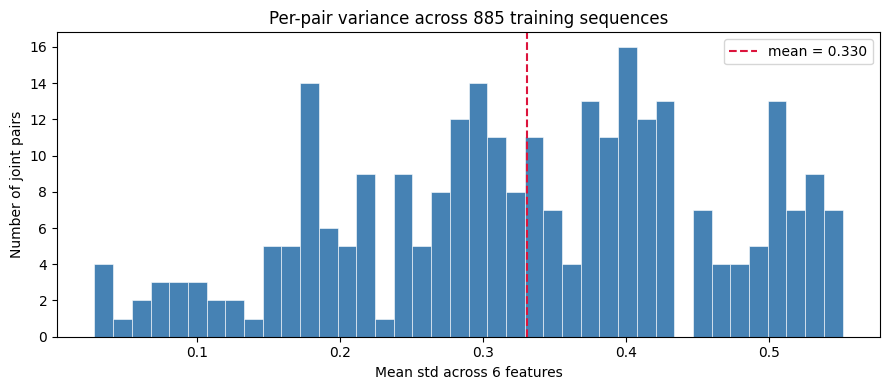


10 MOST STABLE pairs (low variance — relationship consistent across motions):
  Pair                                 mean_std
  ---------------------------------------------
  (left_ankle, left_foot)              0.02805
  (left_wrist, left_hand)              0.03870
  (right_ankle, right_foot)            0.03889
  (right_wrist, right_hand)            0.03907
  (right_elbow, right_wrist)           0.04944
  (left_elbow, left_wrist)             0.05486
  (spine1, spine2)                     0.05886
  (spine3, neck)                       0.07683
  (spine2, spine3)                     0.07704
  (right_elbow, right_hand)            0.07874

10 MOST VARIABLE pairs (high variance — relationship changes with motion):
  Pair                                 mean_std
  ---------------------------------------------
  (right_ankle, left_hand)             0.55132
  (right_foot, right_hand)             0.54860
  (left_foot, left_hand)               0.54741
  (left_ankle, right_hand)             0.5

In [16]:
pair_variance = []
for i, j in pairs:
    mean_std = float(table_std[i, j].mean())
    pair_variance.append((i, j, mean_std))

pair_variance.sort(key=lambda x: x[2])

variances = np.array([v for _, _, v in pair_variance])

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(variances, bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Mean std across 6 features')
ax.set_ylabel('Number of joint pairs')
ax.set_title('Per-pair variance across 885 training sequences')
ax.axvline(variances.mean(), color='crimson', linestyle='--', label=f'mean = {variances.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.show()

print('\n10 MOST STABLE pairs (low variance — relationship consistent across motions):')
print(f'  {"Pair":<35}  mean_std')
print('  ' + '-' * 45)
for i, j, v in pair_variance[:10]:
    print(f'  ({JOINT_NAMES[i]}, {JOINT_NAMES[j]}){" "*(35-len(JOINT_NAMES[i])-len(JOINT_NAMES[j])-4)}  {v:.5f}')

print('\n10 MOST VARIABLE pairs (high variance — relationship changes with motion):')
print(f'  {"Pair":<35}  mean_std')
print('  ' + '-' * 45)
for i, j, v in pair_variance[-10:][::-1]:
    print(f'  ({JOINT_NAMES[i]}, {JOINT_NAMES[j]}){" "*(35-len(JOINT_NAMES[i])-len(JOINT_NAMES[j])-4)}  {v:.5f}')

**What to expect:** Pairs of joints on the same rigid body segment (e.g. left_ankle / left_foot, left_wrist / left_hand) should be most stable because they move as one unit. Pairs spanning large kinematic distance (e.g. head / right_foot) should be most variable because their relative motion depends heavily on the activity.

### Section 2: Feature Discriminability Heatmap

For each pair `(i, j)` we have a 6-D vector `table_mean[i, j]`. We compute the Euclidean distance between every two such vectors to make a **276×276 pairwise distance matrix**, then collapse it into a **24×24 heatmap** by averaging over the second index.

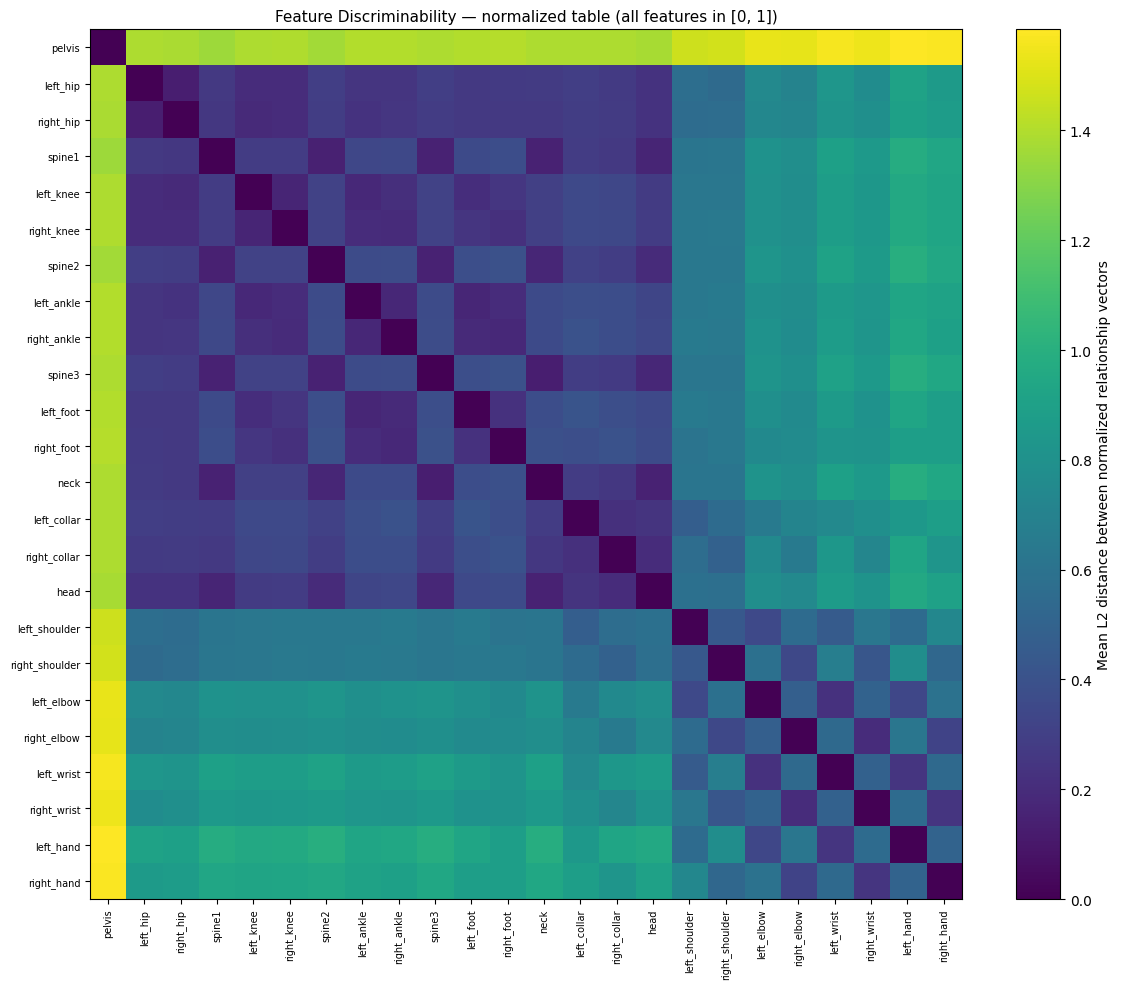

In [17]:
vec = table_mean_normalized   # [24, 24, 6]  — all features in [0, 1]

# dist_map[i,j] = mean over k of ||table_mean_normalized[i,k] - table_mean_normalized[j,k]||
dist_map = np.zeros((N_JOINTS, N_JOINTS))
for i in range(N_JOINTS):
    for j in range(N_JOINTS):
        diffs = vec[i] - vec[j]   # [24, 6]
        dist_map[i, j] = np.linalg.norm(diffs, axis=-1).mean()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(dist_map, cmap='viridis', aspect='auto')
plt.colorbar(im, ax=ax, label='Mean L2 distance between normalized relationship vectors')
ax.set_xticks(range(N_JOINTS))
ax.set_yticks(range(N_JOINTS))
ax.set_xticklabels(JOINT_NAMES, rotation=90, fontsize=7)
ax.set_yticklabels(JOINT_NAMES, fontsize=7)
ax.set_title('Feature Discriminability — normalized table (all features in [0, 1])', fontsize=11)
plt.tight_layout()
plt.show()

**What to expect:** The diagonal is 0 (a joint compared with itself). Joints within the same body region (spine cluster: 0,3,6,9,12; leg cluster: 1,4,7,10 vs 2,5,8,11) should form visible **low-distance blocks** off-diagonal — they look similar to each other. Head/neck (15,12) and extremities (feet 10,11; hands 22,23) should be clearly separated from everything else — high distances to most other joints.

### Section 3: Physical Distance vs Feature Distance Correlation

We compare the **Euclidean distance in 3D space** between joints (from `joint.position` frame 0) against the **L2 distance of the relationship vector** from the global mean. If the lookup table captures meaningful biomechanical relationships, joints that are physically close should have similar relationship profiles.

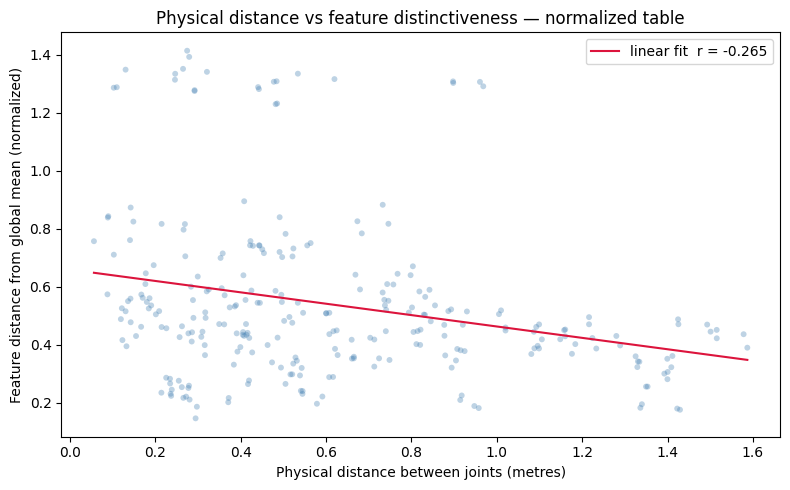

Pearson r = -0.2654


In [18]:
# Load frame-0 positions from first training file
data0 = torch.load(train_files[0], map_location='cpu', weights_only=False)
pos0  = data0['joint']['position'].numpy()[0]   # [24, 3]

# Global mean normalized relationship vector across all pairs
all_vecs = np.array([table_mean_normalized[i, j] for i, j in pairs])  # [276, 6]
global_mean_vec = all_vecs.mean(axis=0)                                 # [6]

phys_dists, feat_dists = [], []

for i, j in pairs:
    phys_d = float(np.linalg.norm(pos0[i] - pos0[j]))
    feat_d = float(np.linalg.norm(table_mean_normalized[i, j] - global_mean_vec))
    phys_dists.append(phys_d)
    feat_dists.append(feat_d)

phys_dists = np.array(phys_dists)
feat_dists = np.array(feat_dists)
corr = float(np.corrcoef(phys_dists, feat_dists)[0, 1])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(phys_dists, feat_dists, alpha=0.35, s=18, color='steelblue', edgecolors='none')
m_fit, b_fit = np.polyfit(phys_dists, feat_dists, 1)
xs = np.linspace(phys_dists.min(), phys_dists.max(), 200)
ax.plot(xs, m_fit*xs + b_fit, color='crimson', linewidth=1.5, label=f'linear fit  r = {corr:.3f}')
ax.set_xlabel('Physical distance between joints (metres)')
ax.set_ylabel('Feature distance from global mean (normalized)')
ax.set_title('Physical distance vs feature distinctiveness — normalized table')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Pearson r = {corr:.4f}')

**What to expect:** A positive correlation (r > 0.3) means joints that are physically far apart have more distinctive relationship profiles, which is what we want — the lookup table should be easy to read for distant pairs. A weak or negative correlation suggests the features are capturing motion correlation rather than anatomy, which is also valid but means the table won't behave like a distance metric.

### Section 4: Symmetry Check

Left-right symmetric joint pairs should have nearly identical relationship vectors with joint 0 (pelvis). Any large difference is a sign of dataset bias (e.g. the subject was predominantly right-handed) or a feature computation bug.

In [19]:
SYMMETRIC_PAIRS = [
    (1,  2,  'hip'),
    (4,  5,  'knee'),
    (7,  8,  'ankle'),
    (10, 11, 'foot'),
    (13, 14, 'collar'),
    (16, 17, 'shoulder'),
    (18, 19, 'elbow'),
    (20, 21, 'wrist'),
    (22, 23, 'hand'),
]

PELVIS = 0

header_pair = 'Symmetric pair'
header_dist = '||vec_left - vec_right||'
print(f'{header_pair:<30}  {header_dist:>26}  Feature diffs (per dim)')
print('-' * 100)

sym_distances = []
for left, right, label in SYMMETRIC_PAIRS:
    vec_l = table_mean_normalized[left,  PELVIS]
    vec_r = table_mean_normalized[right, PELVIS]
    dist  = float(np.linalg.norm(vec_l - vec_r))
    diffs = np.abs(vec_l - vec_r)
    sym_distances.append(dist)
    pair_str = f'left_{label} vs right_{label}'
    print(f'  {pair_str:<28}  {dist:>26.5f}  {" ".join(f"{d:.3f}" for d in diffs)}')

print()
print(f'Feature names (per-dim order): {FEAT_NAMES}')
print()
print(f'Mean symmetry distance: {np.mean(sym_distances):.5f}')
worst_idx = int(np.argmax(sym_distances))
print(f'Max  symmetry distance: {np.max(sym_distances):.5f}  <- {SYMMETRIC_PAIRS[worst_idx][2]}')

Symmetric pair                    ||vec_left - vec_right||  Feature diffs (per dim)
----------------------------------------------------------------------------------------------------
  left_hip vs right_hip                            0.01040  0.000 0.000 0.000 0.009 0.002 0.005
  left_knee vs right_knee                          0.00785  0.000 0.000 0.000 0.004 0.007 0.000
  left_ankle vs right_ankle                        0.02569  0.000 0.000 0.000 0.022 0.004 0.013
  left_foot vs right_foot                          0.06122  0.000 0.000 0.000 0.003 0.013 0.060
  left_collar vs right_collar                      0.02941  0.000 0.000 0.000 0.002 0.011 0.027
  left_shoulder vs right_shoulder                     0.03116  0.000 0.000 0.000 0.005 0.026 0.017
  left_elbow vs right_elbow                        0.06617  0.000 0.000 0.000 0.021 0.038 0.050
  left_wrist vs right_wrist                        0.11024  0.000 0.000 0.000 0.037 0.028 0.100
  left_hand vs right_hand                   

**What to expect:** All distances should be small (ideally < 0.2). The foot and hand pairs might show slightly larger asymmetry due to ground contact differences (right-foot-dominant gait) or dominant-hand bias. Large asymmetry in shoulder/elbow/wrist pairs may indicate activity imbalance in the training data.

### Section 5: Kinematic Chain Analysis

Within a kinematic chain (e.g. hip → knee → ankle → foot), joints that are adjacent should be most correlated. The `cross_corr_peak` (feature 0) should **decrease monotonically** as we move further along the chain.

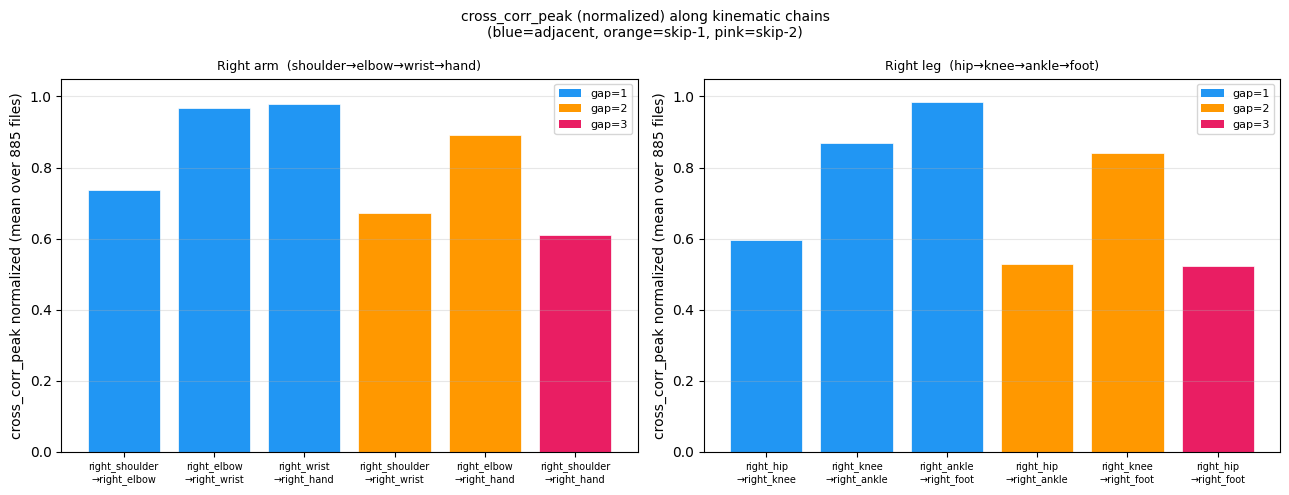

In [20]:
chains = {
    'Right arm  (shoulder→elbow→wrist→hand)':  [17, 19, 21, 23],
    'Right leg  (hip→knee→ankle→foot)':        [ 2,  5,  8, 11],
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('cross_corr_peak (normalized) along kinematic chains\n(blue=adjacent, orange=skip-1, pink=skip-2)', fontsize=10)

for ax, (chain_name, chain) in zip(axes, chains.items()):
    n = len(chain)
    results = {}
    for gap in range(1, n):
        for start in range(n - gap):
            a, b = chain[start], chain[start + gap]
            i, j = (a, b) if a < b else (b, a)
            val = float(table_mean_normalized[i, j, 0])   # feature 0 = cross_corr_peak (normalized)
            key = f'{JOINT_NAMES[a]}\n→{JOINT_NAMES[b]}'
            results[key] = (gap, val)

    labels     = list(results.keys())
    gaps       = [results[k][0] for k in labels]
    vals       = [results[k][1] for k in labels]
    colors     = ['#2196F3', '#FF9800', '#E91E63']
    bar_colors = [colors[g - 1] for g in gaps]

    ax.bar(range(len(labels)), vals, color=bar_colors, edgecolor='white', linewidth=0.5)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=7)
    ax.set_ylabel('cross_corr_peak normalized (mean over 885 files)')
    ax.set_title(chain_name, fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.grid(axis='y', alpha=0.3)

    from matplotlib.patches import Patch
    legend_els = [Patch(facecolor=colors[g-1], label=f'gap={g}') for g in range(1, n)]
    ax.legend(handles=legend_els, fontsize=8)

plt.tight_layout()
plt.show()

**What to expect:** Adjacent joint pairs (gap=1, blue) should have the highest `cross_corr_peak`. Pairs with one joint in between (gap=2, orange) should be lower, and pairs spanning the full chain (gap=3, pink) should be lowest. If the trend reverses at any point it may indicate that two joints are mechanically coupled (e.g. ankle + foot move together more than knee + ankle).

### Section 6: Most and Least Discriminative Pairs

For each pair `(i, j)` we compute its **mean L2 distance to all other pairs' relationship vectors**. A high mean distance means the pair has a *unique* profile — easy to match. A low mean distance means it looks like many other pairs — a potential source of confusion.

In [21]:
pair_vecs = np.array([table_mean_normalized[i, j] for i, j in pairs])   # [276, 6]

# pairwise L2 distance matrix across all 276 pairs
diff = pair_vecs[:, None, :] - pair_vecs[None, :, :]          # [276, 276, 6]
dist_matrix_276 = np.linalg.norm(diff, axis=-1)               # [276, 276]

# mean distance to all *other* pairs (exclude diagonal)
np.fill_diagonal(dist_matrix_276, 0.0)
mean_dist_to_others = dist_matrix_276.sum(axis=1) / (len(pairs) - 1)

ranked = sorted(zip(mean_dist_to_others, pairs), key=lambda x: x[0])

print('Top 10 MOST DISCRIMINATIVE pairs (unique profile → matcher will be confident):')
print(f'  {"Pair":<40}  mean dist to others')
print('  ' + '-' * 62)
for dist, (i, j) in reversed(ranked[-10:]):
    pair_str = f'({JOINT_NAMES[i]}, {JOINT_NAMES[j]})'
    print(f'  {pair_str:<40}  {dist:.5f}')

print()
print('Top 10 LEAST DISCRIMINATIVE pairs (generic profile → matcher may confuse these):')
print(f'  {"Pair":<40}  mean dist to others')
print('  ' + '-' * 62)
for dist, (i, j) in ranked[:10]:
    pair_str = f'({JOINT_NAMES[i]}, {JOINT_NAMES[j]})'
    print(f'  {pair_str:<40}  {dist:.5f}')

Top 10 MOST DISCRIMINATIVE pairs (unique profile → matcher will be confident):
  Pair                                      mean dist to others
  --------------------------------------------------------------
  (pelvis, left_hand)                       1.50852
  (pelvis, right_hand)                      1.48893
  (pelvis, spine2)                          1.44739
  (pelvis, spine1)                          1.44432
  (pelvis, spine3)                          1.43698
  (pelvis, left_wrist)                      1.43549
  (pelvis, neck)                            1.43109
  (pelvis, right_wrist)                     1.41673
  (pelvis, head)                            1.41425
  (pelvis, right_ankle)                     1.40765

Top 10 LEAST DISCRIMINATIVE pairs (generic profile → matcher may confuse these):
  Pair                                      mean dist to others
  --------------------------------------------------------------
  (right_ankle, right_shoulder)             0.54430
  (left_c

**What to expect:** The most discriminative pairs should involve joints at kinematic extremes (e.g. head–foot, hand–foot) — their motion correlation is unusual enough to be unmistakable. The least discriminative pairs tend to involve mid-body joints (spine regions, bilateral symmetric pairs) whose relationship profiles look generically similar to many others. These are the pairs where a matching algorithm should use additional context.

---
## Part 3 — Learned Joint Relationship Model

Replace the 6 hand-crafted features with a learned 64-D embedding using a shared 4-head Transformer encoder and a contrastive (NT-Xent) training objective.

**Architecture:**
- `JointEncoder`: projects `[T, 9]` → `[64]` via a 4-head Transformer + mean pooling
- `PairRelationshipHead`: combines two joint embeddings → `[64]` relationship vector
- Positive pairs for contrastive loss: kinematically adjacent joints from the SMPL skeleton graph

In [6]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

# ── SMPL skeleton adjacency (used to define positive pairs for contrastive loss) ──
SMPL_EDGES = [
    (0, 1), (0, 2), (0, 3),
    (1, 4), (2, 5), (3, 6),
    (4, 7), (5, 8), (6, 9),
    (7, 10), (8, 11), (9, 12),
    (9, 13), (9, 14),
    (12, 15),
    (13, 16), (14, 17),
    (16, 18), (17, 19),
    (18, 20), (19, 21),
    (20, 22), (21, 23),
]

# symmetric adjacency set: (i,j) and (j,i) both included
ADJACENT = {(i, j) for i, j in SMPL_EDGES} | {(j, i) for i, j in SMPL_EDGES}


# ── Sinusoidal positional encoding ───────────────────────────────────────────
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 300, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))  # [1, max_len, d_model]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, T, d_model]
        return self.dropout(x + self.pe[:, :x.size(1)])


# ── Shared joint encoder ──────────────────────────────────────────────────────
class JointEncoder(nn.Module):
    """
    Maps a single joint's time series [B, T, 9] to a fixed embedding [B, d_embed].
    Weights are shared across all joints — joint identity is not an input.
    """
    def __init__(self, in_channels: int = 9, d_model: int = 128,
                 n_heads: int = 4, n_layers: int = 2,
                 d_embed: int = 64, dropout: float = 0.1):
        super().__init__()
        self.input_proj = nn.Linear(in_channels, d_model)
        self.pos_enc    = PositionalEncoding(d_model, dropout=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.pool_proj   = nn.Linear(d_model, d_embed)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, T, 9]
        x = self.pos_enc(self.input_proj(x))   # [B, T, d_model]
        x = self.transformer(x)                # [B, T, d_model]
        x = x.mean(dim=1)                      # [B, d_model]  — mean pooling over time
        return F.normalize(self.pool_proj(x), dim=-1)   # [B, d_embed], L2-normalised


# ── Pairwise relationship head ────────────────────────────────────────────────
class PairRelationshipHead(nn.Module):
    """
    Combines two L2-normalised joint embeddings into a relationship vector.
    Uses concat + difference + elementwise-product so the head sees both
    absolute position in embedding space and relative geometry.
    """
    def __init__(self, d_embed: int = 64, d_out: int = 64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(d_embed * 4, 256),
            nn.ReLU(),
            nn.Linear(256, d_out),
        )

    def forward(self, e_i: torch.Tensor, e_j: torch.Tensor) -> torch.Tensor:
        # e_i, e_j: [B, d_embed]
        combined = torch.cat([e_i, e_j, (e_i - e_j).abs(), e_i * e_j], dim=-1)
        return F.normalize(self.mlp(combined), dim=-1)   # [B, d_out]


# ── Full model ────────────────────────────────────────────────────────────────
class JointRelationshipModel(nn.Module):
    def __init__(self, d_embed: int = 64):
        super().__init__()
        self.encoder = JointEncoder(d_embed=d_embed)
        self.rel_head = PairRelationshipHead(d_embed=d_embed, d_out=d_embed)

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """Encode a single joint time series. x: [B, T, 9] → [B, d_embed]"""
        return self.encoder(x)

    def forward(self, x_i: torch.Tensor, x_j: torch.Tensor) -> torch.Tensor:
        """Encode a joint pair. x_i, x_j: [B, T, 9] → relationship [B, d_embed]"""
        return self.rel_head(self.encoder(x_i), self.encoder(x_j))

    @torch.no_grad()
    def build_lookup_table(self, vimu: torch.Tensor) -> torch.Tensor:
        """
        Build a [24, 24, d_embed] lookup table from a single sequence.
        vimu: [T, 24, 9]
        """
        T, N, C = vimu.shape
        embeddings = self.encoder(vimu.permute(1, 0, 2))   # [24, T, 9] → [24, d_embed]
        table = torch.zeros(N, N, embeddings.size(-1))
        for i in range(N):
            for j in range(N):
                table[i, j] = self.rel_head(
                    embeddings[i].unsqueeze(0),
                    embeddings[j].unsqueeze(0),
                ).squeeze(0)
        return table


# ── NT-Xent contrastive loss ──────────────────────────────────────────────────
class NTXentLoss(nn.Module):
    """
    Contrastive loss over a batch of joint embedding pairs.
    Positive pairs: kinematically adjacent joints (SMPL_EDGES).
    Negatives: all other pairs in the batch.
    """
    def __init__(self, temperature: float = 0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, embeddings: torch.Tensor, joint_indices: torch.Tensor) -> torch.Tensor:
        """
        embeddings:    [B * 24, d_embed]  — one embedding per joint per sequence in batch
        joint_indices: [B * 24]           — which joint (0-23) each embedding belongs to
        """
        n = embeddings.size(0)
        sim = torch.mm(embeddings, embeddings.T) / self.temperature   # [n, n]

        # positive mask: same sequence AND kinematically adjacent joints
        pos_mask = torch.zeros(n, n, dtype=torch.bool, device=embeddings.device)
        for idx_a in range(n):
            for idx_b in range(n):
                ji, jj = int(joint_indices[idx_a]), int(joint_indices[idx_b])
                if idx_a != idx_b and (ji, jj) in ADJACENT:
                    pos_mask[idx_a, idx_b] = True

        # mask out self-similarity on diagonal
        eye = torch.eye(n, dtype=torch.bool, device=embeddings.device)
        sim = sim.masked_fill(eye, float('-inf'))

        # for each anchor, pull positives, push negatives
        loss = 0.0
        count = 0
        for i in range(n):
            pos_idx = pos_mask[i].nonzero(as_tuple=True)[0]
            if len(pos_idx) == 0:
                continue
            log_denom = torch.logsumexp(sim[i], dim=0)
            loss += (log_denom - sim[i, pos_idx]).mean()
            count += 1

        return loss / max(count, 1)


# ── Training loop skeleton ────────────────────────────────────────────────────
def train_one_epoch(model, loss_fn, optimizer, train_files, device, batch_size=8):
    model.train()
    total_loss = 0.0

    for batch_start in range(0, len(train_files), batch_size):
        batch_paths = train_files[batch_start: batch_start + batch_size]

        # load sequences → [B, T, 24, 9]
        sequences = []
        for p in batch_paths:
            d = torch.load(p, map_location='cpu', weights_only=False)
            sequences.append(d['vimu']['vimu_joints'])   # [300, 24, 9]
        seqs = torch.stack(sequences).to(device)         # [B, 300, 24, 9]

        B, T, N, C = seqs.shape

        # encode all joints: reshape to [B*24, T, 9]
        seqs_flat = seqs.permute(0, 2, 1, 3).reshape(B * N, T, C)
        joint_idx = torch.arange(N, device=device).repeat(B)   # [B*24]

        optimizer.zero_grad()
        embeddings = model.encode(seqs_flat)   # [B*24, d_embed]
        loss = loss_fn(embeddings, joint_idx)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / max(len(train_files) // batch_size, 1)


# ── Instantiate (not training yet) ───────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model   = JointRelationshipModel(d_embed=64).to(device)
loss_fn = NTXentLoss(temperature=0.07)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Device  : {device}')
print(f'Params  : {n_params:,}')
print(f'Encoder : {sum(p.numel() for p in model.encoder.parameters()):,}')
print(f'RelHead : {sum(p.numel() for p in model.rel_head.parameters()):,}')
print()
print(model)

Device  : cpu
Params  : 488,320
Encoder : 406,080
RelHead : 82,240

JointRelationshipModel(
  (encoder): JointEncoder(
    (input_proj): Linear(in_features=9, out_features=128, bias=True)
    (pos_enc): PositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
          )
          (linear1): Linear(in_features=128, out_features=512, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=512, out_features=128, bias=True)
          (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
       

Train: 797 files   Val: 88 files
 Epoch    Train loss    Val loss          LR      Time
--------------------------------------------------------
     1       4.78778     4.69919    2.99e-04    158.8s
     2       4.61176     4.53700    2.97e-04    136.1s
     3       4.48028     4.47312    2.93e-04    135.5s
     4       4.41688     4.41451    2.88e-04    136.7s
     5       4.36763     4.41023    2.81e-04    549.7s
     6       4.33749     4.36175    2.73e-04   1881.0s
     7       4.28953     4.40470    2.63e-04    130.2s
     8       4.25577     4.35232    2.53e-04    131.0s
     9       4.22682     4.27100    2.41e-04    132.1s
    10       4.20397     4.24452    2.29e-04    129.9s
    11       4.17435     4.31151    2.15e-04    129.9s
    12       4.15376     4.35201    2.02e-04    130.3s
    13       4.15604     4.27213    1.87e-04   1259.4s
    14       4.12978     4.23241    1.72e-04   1331.9s
    15       4.11282     4.25000    1.58e-04   2744.3s
    16       4.09984     4.260

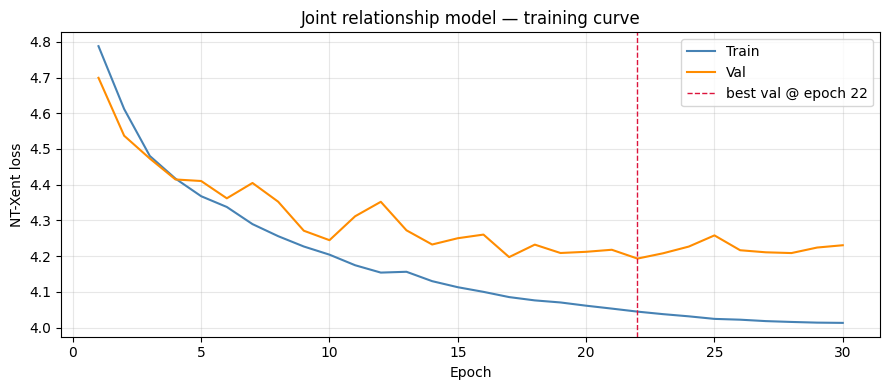

In [ ]:
import random
import time
from pathlib import Path

# ── Config ────────────────────────────────────────────────────────────────────
N_EPOCHS    = 30
BATCH_SIZE  = 8
LR          = 3e-4
VAL_SPLIT   = 0.1        # 10% of files held out for validation
CKPT_PATH   = OUTPUT_DIR / 'joint_rel_model_best.pt'
TEMPERATURE = 0.07

# ── Train / val split ─────────────────────────────────────────────────────────
random.seed(42)
all_files  = list(train_files)
random.shuffle(all_files)
n_val      = max(1, int(len(all_files) * VAL_SPLIT))
val_files  = all_files[:n_val]
trn_files  = all_files[n_val:]
print(f'Train: {len(trn_files)} files   Val: {len(val_files)} files')

# ── Re-instantiate fresh model + scheduler ───────────────────────────────────
model     = JointRelationshipModel(d_embed=64).to(device)
loss_fn   = NTXentLoss(temperature=TEMPERATURE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=LR / 20)


# ── Batch loader ──────────────────────────────────────────────────────────────
def load_batch(paths: list, device: torch.device):
    """Load a list of .pt files → (seqs [B,T,24,9], joint_idx [B*24])."""
    seqs = []
    for p in paths:
        d = torch.load(p, map_location='cpu', weights_only=False)
        seqs.append(d['vimu']['vimu_joints'])       # [300, 24, 9]
    seqs = torch.stack(seqs).to(device)             # [B, 300, 24, 9]
    B, T, N, C = seqs.shape
    seqs_flat  = seqs.permute(0, 2, 1, 3).reshape(B * N, T, C)   # [B*24, T, 9]
    joint_idx  = torch.arange(N, device=device).repeat(B)         # [B*24]
    return seqs_flat, joint_idx


# ── One epoch ─────────────────────────────────────────────────────────────────
def run_epoch(files: list, train: bool) -> float:
    model.train(train)
    ctx  = torch.enable_grad() if train else torch.no_grad()
    total, steps = 0.0, 0

    random.shuffle(files)
    with ctx:
        for start in range(0, len(files), BATCH_SIZE):
            batch_paths = files[start: start + BATCH_SIZE]
            seqs_flat, joint_idx = load_batch(batch_paths, device)

            if train:
                optimizer.zero_grad()

            embeddings = model.encode(seqs_flat)
            loss       = loss_fn(embeddings, joint_idx)

            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total += loss.item()
            steps += 1

    return total / max(steps, 1)


# # ── Training loop ─────────────────────────────────────────────────────────────
# trn_losses, val_losses = [], []
# best_val   = float('inf')
# t0         = time.time()

# print(f'{"Epoch":>6}  {"Train loss":>12}  {"Val loss":>10}  {"LR":>10}  {"Time":>8}')
# print('-' * 56)

# for epoch in range(1, N_EPOCHS + 1):
#     t_ep   = time.time()
#     trn_l  = run_epoch(trn_files, train=True)
#     val_l  = run_epoch(val_files, train=False)
#     scheduler.step()

#     trn_losses.append(trn_l)
#     val_losses.append(val_l)

#     lr_now = scheduler.get_last_lr()[0]
#     elapsed = time.time() - t_ep
#     print(f'{epoch:>6}  {trn_l:>12.5f}  {val_l:>10.5f}  {lr_now:>10.2e}  {elapsed:>7.1f}s')

#     if val_l < best_val:
#         best_val = val_l
#         torch.save({
#             'epoch':       epoch,
#             'model_state': model.state_dict(),
#             'optim_state': optimizer.state_dict(),
#             'val_loss':    best_val,
#             'd_embed':     64,
#         }, CKPT_PATH)

# print(f'\nTotal time : {(time.time() - t0)/60:.1f} min')
# print(f'Best val loss : {best_val:.5f}  (saved → {CKPT_PATH})')

# # ── Loss curve ────────────────────────────────────────────────────────────────
# epochs_ax = range(1, N_EPOCHS + 1)
# fig, ax   = plt.subplots(figsize=(9, 4))
# ax.plot(epochs_ax, trn_losses, label='Train', color='steelblue',  linewidth=1.5)
# ax.plot(epochs_ax, val_losses, label='Val',   color='darkorange', linewidth=1.5)
# ax.axvline(val_losses.index(best_val) + 1, color='crimson', linestyle='--',
#            linewidth=1, label=f'best val @ epoch {val_losses.index(best_val)+1}')
# ax.set_xlabel('Epoch')
# ax.set_ylabel('NT-Xent loss')
# ax.set_title('Joint relationship model — training curve')
# ax.legend()
# ax.grid(alpha=0.3)
# plt.tight_layout() 
# plt.show()

---
## Part 4 — Evaluation of Learned Embeddings

Load the best checkpoint and build a `[24, 24, 64]` learned lookup table by averaging relationship
embeddings across all validation files. Each of the six analyses from Part 2 is then repeated
using the 64-D vectors in place of the 6 hand-crafted features.

> **Note:** Section 4 (symmetry) reports only total L2 distance — per-dimension breakdown is no
> longer interpretable. Section 5 (kinematic chains) uses cosine similarity between joint embeddings
> instead of `cross_corr_peak`.

In [10]:
import random
import time
from pathlib import Path

# ── Config ────────────────────────────────────────────────────────────────────
N_EPOCHS    = 30
BATCH_SIZE  = 8
LR          = 3e-4
VAL_SPLIT   = 0.1        # 10% of files held out for validation
CKPT_PATH   = OUTPUT_DIR / 'joint_rel_model_best.pt'
TEMPERATURE = 0.07
# ── Train / val split ─────────────────────────────────────────────────────────
random.seed(42)
all_files  = list(train_files)
random.shuffle(all_files)
n_val      = max(1, int(len(all_files) * VAL_SPLIT))
val_files  = all_files[:n_val]
trn_files  = all_files[n_val:]
print(f'Train: {len(trn_files)} files   Val: {len(val_files)} files')

Train: 797 files   Val: 88 files


In [11]:
# ── Load best checkpoint ──────────────────────────────────────────────────────
CKPT_PATH   = OUTPUT_DIR / 'joint_rel_model_best.pt'
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
d_embed = ckpt['d_embed']

eval_model = JointRelationshipModel(d_embed=d_embed).to(device)
eval_model.load_state_dict(ckpt['model_state'])
eval_model.eval()
print(f'Loaded checkpoint  epoch={ckpt["epoch"]}  val_loss={ckpt["val_loss"]:.5f}  d_embed={d_embed}')

# ── Build learned lookup table over all val files ─────────────────────────────
# table per file: [24, 24, 64] — averaged to get table_L_mean / table_L_std
N_EVAL   = len(val_files)
all_L    = np.zeros((N_JOINTS, N_JOINTS, N_EVAL, d_embed), dtype=np.float32)

with torch.no_grad():
    for file_idx, fpath in enumerate(tqdm(val_files, desc='Building learned table')):
        data  = torch.load(fpath, map_location='cpu', weights_only=False)
        vimu  = data['vimu']['vimu_joints'].to(device)          # [300, 24, 9]
        table = eval_model.build_lookup_table(vimu).cpu().numpy()  # [24, 24, 64]
        all_L[:, :, file_idx, :] = table

table_L_mean = all_L.mean(axis=2)   # [24, 24, 64]
table_L_std  = all_L.std(axis=2)    # [24, 24, 64]

print(f'\nLearned table shape : {table_L_mean.shape}')
print(f'  value range       : [{table_L_mean.min():.4f}, {table_L_mean.max():.4f}]')
print(f'  mean entry norm   : {np.linalg.norm(table_L_mean, axis=-1).mean():.4f}')

# pairs list (re-define in case this cell is run standalone)
pairs = [(i, j) for i in range(N_JOINTS) for j in range(i + 1, N_JOINTS)]

Loaded checkpoint  epoch=22  val_loss=4.19302  d_embed=64


Building learned table: 100%|██████████| 88/88 [00:03<00:00, 23.96it/s]


Learned table shape : (24, 24, 64)
  value range       : [-0.3173, 0.3090]
  mean entry norm   : 0.9871


### Eval Section 1: Per-Pair Variance Across Sequences

Same as Part 2 Section 1 — average the per-dim std across all 64 embedding dimensions.
Low variance = the model produces a consistent relationship for this pair regardless of motion.
Compare the histogram shape and the top/bottom-10 lists against the hand-crafted version.

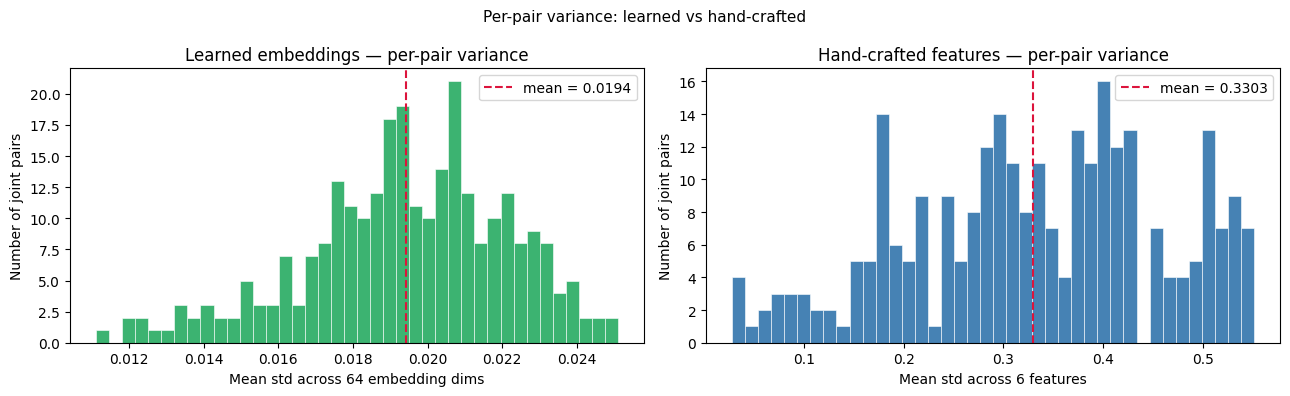


Learned — 10 MOST STABLE pairs:
  Pair                                      mean_std
  ----------------------------------------------------
  (right_elbow, right_wrist)                  0.01112
  (right_shoulder, right_elbow)               0.01184
  (left_shoulder, right_shoulder)             0.01189
  (right_wrist, right_hand)                   0.01222
  (right_elbow, right_hand)                   0.01242
  (right_shoulder, right_wrist)               0.01280
  (left_shoulder, left_elbow)                 0.01296
  (right_shoulder, right_hand)                0.01326
  (left_elbow, right_elbow)                   0.01329
  (left_shoulder, right_elbow)                0.01343

Learned — 10 MOST VARIABLE pairs:
  Pair                                      mean_std
  ----------------------------------------------------
  (spine2, left_foot)                         0.02510
  (right_foot, head)                          0.02476
  (spine3, left_foot)                         0.02462
  (left_foot, 

In [22]:
# mean std across all 64 embedding dims for each pair
pair_var_L = []
for i, j in pairs:
    mean_std = float(table_L_std[i, j].mean())
    pair_var_L.append((i, j, mean_std))

pair_var_L.sort(key=lambda x: x[2])
variances_L = np.array([v for _, _, v in pair_var_L])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# learned
axes[0].hist(variances_L, bins=40, color='mediumseagreen', edgecolor='white', linewidth=0.4)
axes[0].axvline(variances_L.mean(), color='crimson', linestyle='--',
                label=f'mean = {variances_L.mean():.4f}')
axes[0].set_xlabel('Mean std across 64 embedding dims')
axes[0].set_ylabel('Number of joint pairs')
axes[0].set_title('Learned embeddings — per-pair variance')
axes[0].legend()

# hand-crafted (reloaded for side-by-side comparison)
variances_hc = np.array([float(table_std[i, j].mean()) for i, j in pairs])
axes[1].hist(variances_hc, bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
axes[1].axvline(variances_hc.mean(), color='crimson', linestyle='--',
                label=f'mean = {variances_hc.mean():.4f}')
axes[1].set_xlabel('Mean std across 6 features')
axes[1].set_ylabel('Number of joint pairs')
axes[1].set_title('Hand-crafted features — per-pair variance')
axes[1].legend()

plt.suptitle('Per-pair variance: learned vs hand-crafted', fontsize=11)
plt.tight_layout()
plt.show()

print('\nLearned — 10 MOST STABLE pairs:')
print(f'  {"Pair":<40}  mean_std')
print('  ' + '-' * 52)
for i, j, v in pair_var_L[:10]:
    print(f'  ({JOINT_NAMES[i]}, {JOINT_NAMES[j]}){" "*(38-len(JOINT_NAMES[i])-len(JOINT_NAMES[j]))}  {v:.5f}')

print('\nLearned — 10 MOST VARIABLE pairs:')
print(f'  {"Pair":<40}  mean_std')
print('  ' + '-' * 52)
for i, j, v in pair_var_L[-10:][::-1]:
    print(f'  ({JOINT_NAMES[i]}, {JOINT_NAMES[j]}){" "*(38-len(JOINT_NAMES[i])-len(JOINT_NAMES[j]))}  {v:.5f}')

### Eval Section 2: Discriminability Heatmap

For each joint `i`, its "profile" is the row `table_L_mean[i]` — a `[24, 64]` matrix of
relationship vectors to all other joints. `dist_map[i, j]` is the mean L2 distance between
joint `i`'s profile and joint `j`'s profile. High values = the two joints relate to the rest
of the body in very different ways. Shown side-by-side with the hand-crafted version.

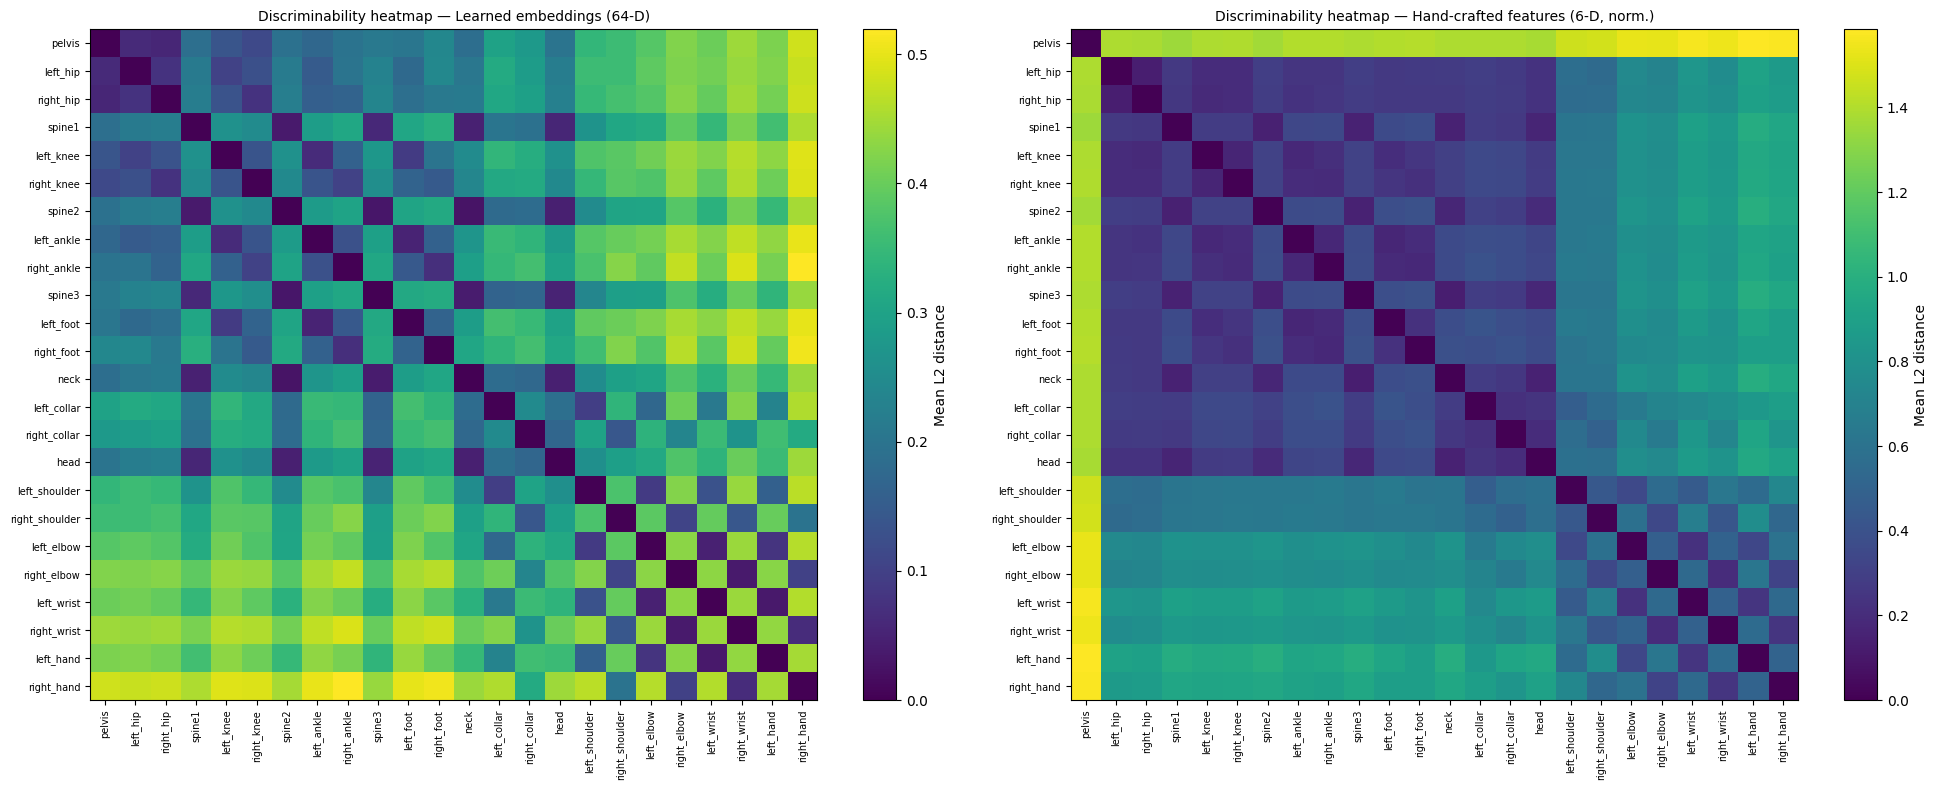

                                   learned    hand-crafted
----------------------------------------------------------
mean off-diag dist                  0.2978          0.6141
max  off-diag dist                  0.5194          1.5842
min  off-diag dist                  0.0277          0.1341


In [23]:
def build_dist_map(table):
    """table: [24, 24, D] → dist_map [24, 24] where entry [i,j] = mean_k ||table[i,k] - table[j,k]||"""
    N = table.shape[0]
    dist_map = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            diffs = table[i] - table[j]             # [24, D]
            dist_map[i, j] = np.linalg.norm(diffs, axis=-1).mean()
    return dist_map

dist_map_L  = build_dist_map(table_L_mean)
dist_map_hc = build_dist_map(table_mean_normalized)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, dm, title, cmap in [
    (axes[0], dist_map_L,  'Learned embeddings (64-D)',          'viridis'),
    (axes[1], dist_map_hc, 'Hand-crafted features (6-D, norm.)', 'viridis'),
]:
    im = ax.imshow(dm, cmap=cmap, aspect='auto')
    plt.colorbar(im, ax=ax, label='Mean L2 distance')
    ax.set_xticks(range(N_JOINTS))
    ax.set_yticks(range(N_JOINTS))
    ax.set_xticklabels(JOINT_NAMES, rotation=90, fontsize=7)
    ax.set_yticklabels(JOINT_NAMES, fontsize=7)
    ax.set_title(f'Discriminability heatmap — {title}', fontsize=10)

plt.tight_layout()
plt.show()

# summary stats
print(f'{"":30s}  {"learned":>10}  {"hand-crafted":>14}')
print('-' * 58)
off_diag = ~np.eye(N_JOINTS, dtype=bool)
print(f'{"mean off-diag dist":30s}  {dist_map_L[off_diag].mean():10.4f}  {dist_map_hc[off_diag].mean():14.4f}')
print(f'{"max  off-diag dist":30s}  {dist_map_L[off_diag].max():10.4f}  {dist_map_hc[off_diag].max():14.4f}')
print(f'{"min  off-diag dist":30s}  {dist_map_L[off_diag].min():10.4f}  {dist_map_hc[off_diag].min():14.4f}')

### Eval Section 3: Physical Distance vs Feature Distance Correlation

Same scatter plot as Part 2 Section 3. A higher Pearson r than the hand-crafted version
means the learned embeddings better reflect biomechanical structure (anatomically distant
joints have more distinct relationship profiles).

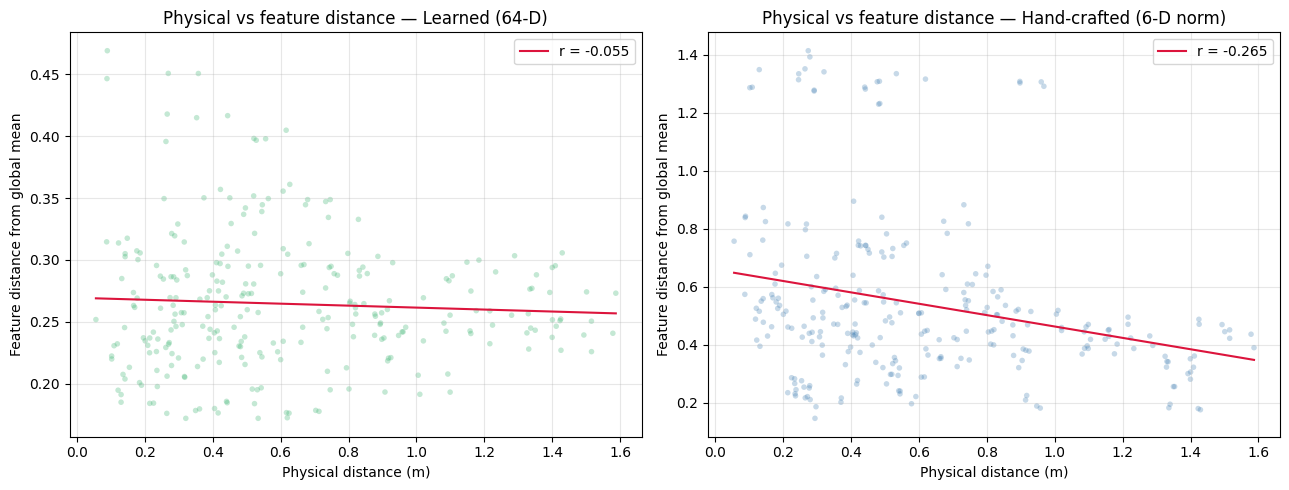

Pearson r — learned      : -0.0553
Pearson r — hand-crafted : -0.2654
Delta                    : +0.2101  (learned better)


In [24]:
data0 = torch.load(train_files[0], map_location='cpu', weights_only=False)
pos0  = data0['joint']['position'].numpy()[0]   # [24, 3]

def phys_vs_feat_corr(table, label, ax, color):
    all_vecs      = np.array([table[i, j] for i, j in pairs])
    global_mean   = all_vecs.mean(axis=0)
    phys_d, feat_d = [], []
    for i, j in pairs:
        phys_d.append(float(np.linalg.norm(pos0[i] - pos0[j])))
        feat_d.append(float(np.linalg.norm(table[i, j] - global_mean)))
    phys_d, feat_d = np.array(phys_d), np.array(feat_d)
    r = float(np.corrcoef(phys_d, feat_d)[0, 1])
    m, b = np.polyfit(phys_d, feat_d, 1)
    xs = np.linspace(phys_d.min(), phys_d.max(), 200)
    ax.scatter(phys_d, feat_d, alpha=0.3, s=16, color=color, edgecolors='none')
    ax.plot(xs, m * xs + b, color='crimson', linewidth=1.5, label=f'r = {r:.3f}')
    ax.set_xlabel('Physical distance (m)')
    ax.set_ylabel('Feature distance from global mean')
    ax.set_title(f'Physical vs feature distance — {label}')
    ax.legend()
    ax.grid(alpha=0.3)
    return r

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
r_L  = phys_vs_feat_corr(table_L_mean,           'Learned (64-D)',          axes[0], 'mediumseagreen')
r_hc = phys_vs_feat_corr(table_mean_normalized,  'Hand-crafted (6-D norm)', axes[1], 'steelblue')
plt.tight_layout()
plt.show()

print(f'Pearson r — learned      : {r_L:.4f}')
print(f'Pearson r — hand-crafted : {r_hc:.4f}')
delta = r_L - r_hc
print(f'Delta                    : {delta:+.4f}  ({"learned better" if delta > 0 else "hand-crafted better"})')

### Eval Section 4: Symmetry Check

Left/right symmetric joint pairs should produce nearly identical relationship embeddings
relative to the pelvis. Total L2 distance is reported; per-dimension breakdown is omitted
because the 64 learned dims are not independently interpretable.
A lower distance than the hand-crafted version means the model is less biased by dominant-side motion.

  Pair                           learned ||Δ||    hand-crafted ||Δ||    better
  ----------------------------------------------------------------------------
  left_hip vs right_hip                0.06230               0.01040   hand-cr
  left_knee vs right_knee               0.11306               0.00785   hand-cr
  left_ankle vs right_ankle              0.12095               0.02569   hand-cr
  left_foot vs right_foot               0.15024               0.06122   hand-cr
  left_collar vs right_collar             0.22078               0.02941   hand-cr
  left_shoulder vs right_shoulder           0.34319               0.03116   hand-cr
  left_elbow vs right_elbow              0.40465               0.06617   hand-cr
  left_wrist vs right_wrist              0.42247               0.11024   hand-cr
  left_hand vs right_hand               0.43623               0.12459   hand-cr

  Mean — learned: 0.25265   hand-crafted: 0.05186
  Max  — learned: 0.43623  (hand)


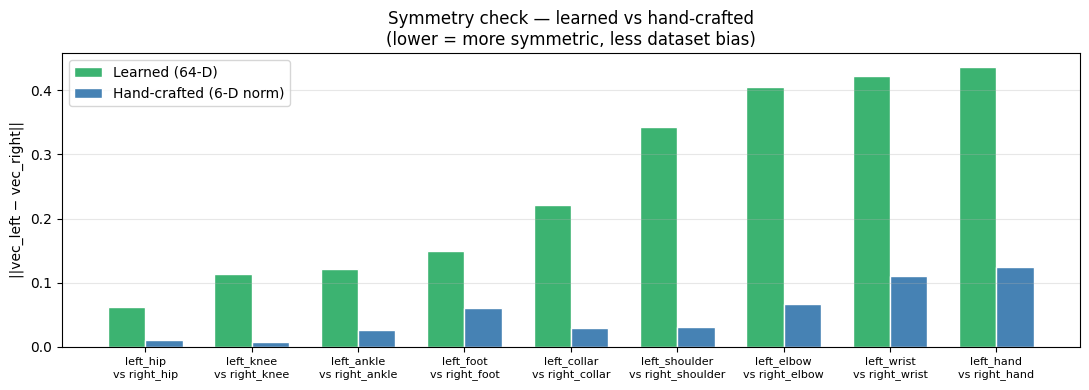

In [25]:
SYMMETRIC_PAIRS = [
    (1,  2,  'hip'),
    (4,  5,  'knee'),
    (7,  8,  'ankle'),
    (10, 11, 'foot'),
    (13, 14, 'collar'),
    (16, 17, 'shoulder'),
    (18, 19, 'elbow'),
    (20, 21, 'wrist'),
    (22, 23, 'hand'),
]
PELVIS = 0

sym_L, sym_hc = [], []
pair_labels = []

for left, right, label in SYMMETRIC_PAIRS:
    d_L  = float(np.linalg.norm(table_L_mean[left, PELVIS] - table_L_mean[right, PELVIS]))
    d_hc = float(np.linalg.norm(table_mean_normalized[left, PELVIS] - table_mean_normalized[right, PELVIS]))
    sym_L.append(d_L)
    sym_hc.append(d_hc)
    pair_labels.append(f'left_{label}\nvs right_{label}')

# table
print(f'  {"Pair":<28}  {"learned ||Δ||":>14}  {"hand-crafted ||Δ||":>20}  {"better":>8}')
print('  ' + '-' * 76)
for (left, right, label), d_L, d_hc in zip(SYMMETRIC_PAIRS, sym_L, sym_hc):
    better = 'learned' if d_L < d_hc else 'hand-cr'
    print(f'  left_{label} vs right_{label:<10}  {d_L:14.5f}  {d_hc:20.5f}  {better:>8}')

print()
print(f'  Mean — learned: {np.mean(sym_L):.5f}   hand-crafted: {np.mean(sym_hc):.5f}')
print(f'  Max  — learned: {np.max(sym_L):.5f}  ({SYMMETRIC_PAIRS[int(np.argmax(sym_L))][2]})')

# bar chart
x = np.arange(len(SYMMETRIC_PAIRS))
w = 0.35
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(x - w/2, sym_L,  w, label='Learned (64-D)',          color='mediumseagreen', edgecolor='white')
ax.bar(x + w/2, sym_hc, w, label='Hand-crafted (6-D norm)', color='steelblue',      edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(pair_labels, fontsize=8)
ax.set_ylabel('||vec_left − vec_right||')
ax.set_title('Symmetry check — learned vs hand-crafted\n(lower = more symmetric, less dataset bias)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Eval Section 5: Kinematic Chain Analysis

Instead of `cross_corr_peak` (a named feature), we use **cosine similarity between joint
embeddings** as the adjacency signal. Adjacent joints in the skeleton were trained as positive
pairs, so their embeddings should be pulled closer — cosine similarity should decrease
monotonically as chain gap increases.

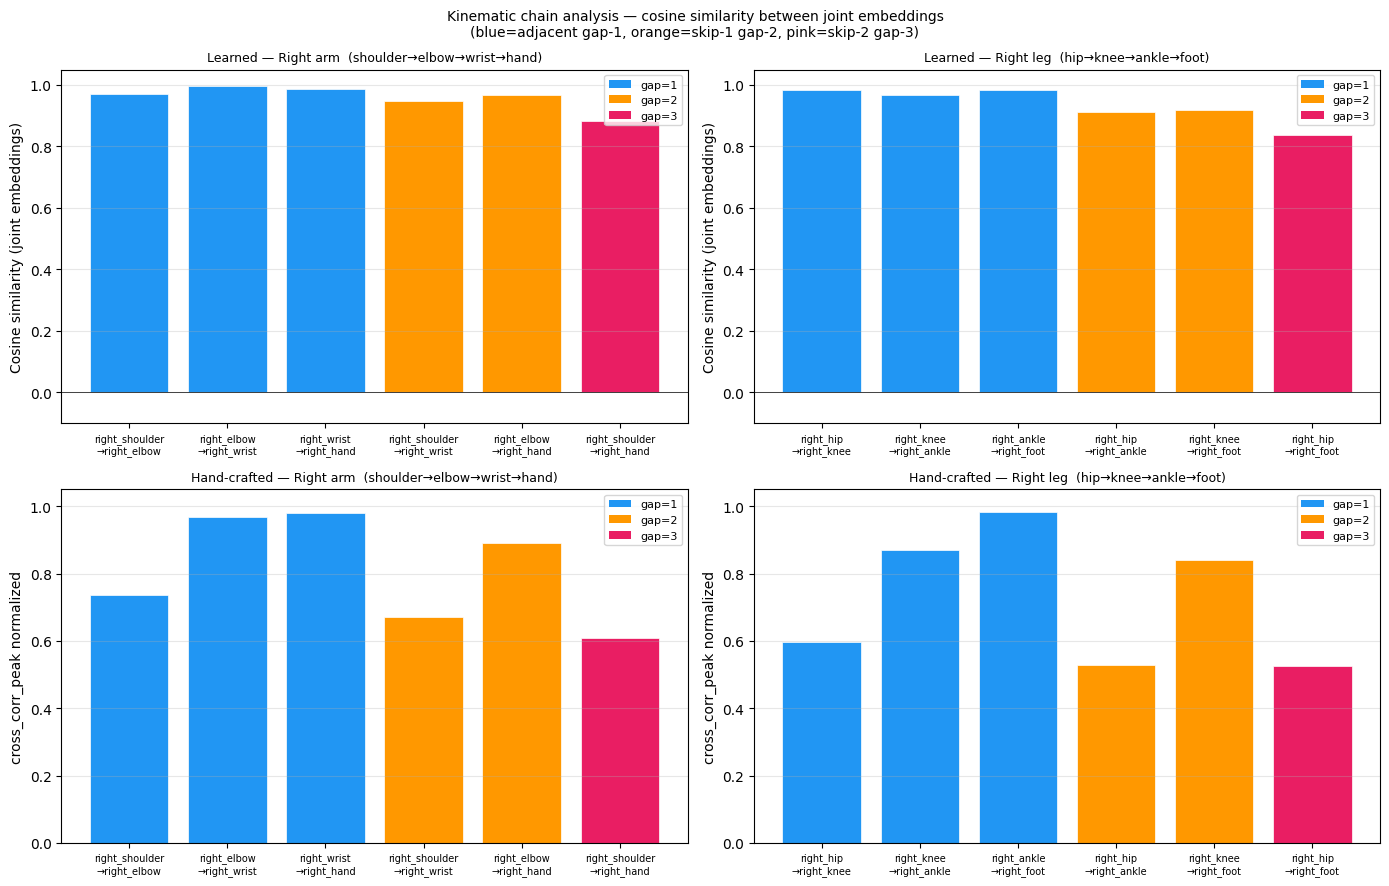

Monotonicity check — does cosine similarity decrease with chain gap?
  Chain                                          gap-1 mean  gap-2 mean  gap-3 mean  monotonic?
  -------------------------------------------------------------------------------------
  Right arm  (shoulder→elbow→wrist→hand)         0.9847  0.9574  0.8820  yes ✓
  Right leg  (hip→knee→ankle→foot)               0.9784  0.9152  0.8360  yes ✓


In [26]:
chains = {
    'Right arm  (shoulder→elbow→wrist→hand)': [17, 19, 21, 23],
    'Right leg  (hip→knee→ankle→foot)':       [ 2,  5,  8, 11],
}

# pre-compute mean joint embeddings (encode each joint over all val files)
# joint_emb[j] = mean embedding of joint j across val files
with torch.no_grad():
    joint_emb_all = np.zeros((N_JOINTS, len(val_files), d_embed), dtype=np.float32)
    for file_idx, fpath in enumerate(val_files):
        data = torch.load(fpath, map_location='cpu', weights_only=False)
        vimu = data['vimu']['vimu_joints'].to(device)               # [300, 24, 9]
        x    = vimu.permute(1, 0, 2)                                # [24, 300, 9]
        embs = eval_model.encode(x).cpu().numpy()                   # [24, 64]
        joint_emb_all[:, file_idx, :] = embs
joint_emb_mean = joint_emb_all.mean(axis=1)   # [24, 64]

# cosine similarity between joint embeddings (L2-normed, so dot product = cosine sim)
norms = np.linalg.norm(joint_emb_mean, axis=-1, keepdims=True) + 1e-8
joint_emb_normed = joint_emb_mean / norms   # [24, 64]

from matplotlib.patches import Patch

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Kinematic chain analysis — cosine similarity between joint embeddings\n'
             '(blue=adjacent gap-1, orange=skip-1 gap-2, pink=skip-2 gap-3)', fontsize=10)

colors = ['#2196F3', '#FF9800', '#E91E63']

for col, (chain_name, chain) in enumerate(chains.items()):
    n = len(chain)

    # learned
    ax_L = axes[0, col]
    results_L = {}
    for gap in range(1, n):
        for start in range(n - gap):
            a, b   = chain[start], chain[start + gap]
            cos_sim = float(np.dot(joint_emb_normed[a], joint_emb_normed[b]))
            key    = f'{JOINT_NAMES[a]}\n→{JOINT_NAMES[b]}'
            results_L[key] = (gap, cos_sim)

    labels   = list(results_L.keys())
    gaps_L   = [results_L[k][0] for k in labels]
    vals_L   = [results_L[k][1] for k in labels]
    bar_cols = [colors[g - 1] for g in gaps_L]
    ax_L.bar(range(len(labels)), vals_L, color=bar_cols, edgecolor='white', linewidth=0.5)
    ax_L.set_xticks(range(len(labels)))
    ax_L.set_xticklabels(labels, fontsize=7)
    ax_L.set_ylabel('Cosine similarity (joint embeddings)')
    ax_L.set_title(f'Learned — {chain_name}', fontsize=9)
    ax_L.set_ylim(-0.1, 1.05)
    ax_L.axhline(0, color='black', linewidth=0.5)
    ax_L.grid(axis='y', alpha=0.3)
    ax_L.legend(handles=[Patch(facecolor=colors[g-1], label=f'gap={g}') for g in range(1, n)], fontsize=8)

    # hand-crafted (cross_corr_peak, feature 0, normalized)
    ax_hc = axes[1, col]
    results_hc = {}
    for gap in range(1, n):
        for start in range(n - gap):
            a, b = chain[start], chain[start + gap]
            i, j = (a, b) if a < b else (b, a)
            val  = float(table_mean_normalized[i, j, 0])
            key  = f'{JOINT_NAMES[a]}\n→{JOINT_NAMES[b]}'
            results_hc[key] = (gap, val)

    gaps_hc  = [results_hc[k][0] for k in labels]
    vals_hc  = [results_hc[k][1] for k in labels]
    bar_cols = [colors[g - 1] for g in gaps_hc]
    ax_hc.bar(range(len(labels)), vals_hc, color=bar_cols, edgecolor='white', linewidth=0.5)
    ax_hc.set_xticks(range(len(labels)))
    ax_hc.set_xticklabels(labels, fontsize=7)
    ax_hc.set_ylabel('cross_corr_peak normalized')
    ax_hc.set_title(f'Hand-crafted — {chain_name}', fontsize=9)
    ax_hc.set_ylim(0, 1.05)
    ax_hc.axhline(0, color='black', linewidth=0.5)
    ax_hc.grid(axis='y', alpha=0.3)
    ax_hc.legend(handles=[Patch(facecolor=colors[g-1], label=f'gap={g}') for g in range(1, n)], fontsize=8)

plt.tight_layout()
plt.show()

# monotonicity check
print('Monotonicity check — does cosine similarity decrease with chain gap?')
print(f'  {"Chain":<45}  gap-1 mean  gap-2 mean  gap-3 mean  monotonic?')
print('  ' + '-' * 85)
for chain_name, chain in chains.items():
    n = len(chain)
    by_gap = {g: [] for g in range(1, n)}
    for gap in range(1, n):
        for start in range(n - gap):
            a, b = chain[start], chain[start + gap]
            by_gap[gap].append(float(np.dot(joint_emb_normed[a], joint_emb_normed[b])))
    means = [np.mean(by_gap[g]) for g in range(1, n)]
    mono  = all(means[k] > means[k+1] for k in range(len(means)-1))
    vals  = '  '.join(f'{m:.4f}' for m in means)
    print(f'  {chain_name:<45}  {vals}  {"yes ✓" if mono else "no  ✗"}')

### Eval Section 6: Most and Least Discriminative Pairs

Same ranking as Part 2 Section 6 — mean L2 distance of each pair's relationship embedding
to all other pairs' embeddings. Shown side-by-side with the hand-crafted ranking so you can
see whether the model agrees on which pairs are hardest to distinguish.


Learned embeddings (64-D)
  Pair                                      mean dist
  ----------------------------------------------------
  MOST discriminative:
    (right_wrist, right_hand)                 0.53178
    (left_wrist, left_hand)                   0.51691
    (right_elbow, right_wrist)                0.51618
    (right_elbow, right_hand)                 0.51522
    (right_wrist, left_hand)                  0.49220
    (left_elbow, left_wrist)                  0.49181
    (left_elbow, left_hand)                   0.48955
    (right_elbow, left_wrist)                 0.47656
    (right_elbow, left_hand)                  0.47620
    (right_shoulder, right_hand)              0.47486
  LEAST discriminative:
    (pelvis, spine3)                          0.30346
    (pelvis, neck)                            0.30386
    (pelvis, head)                            0.30434
    (right_hip, spine3)                       0.30545
    (pelvis, spine2)                          0.30551
    (ri

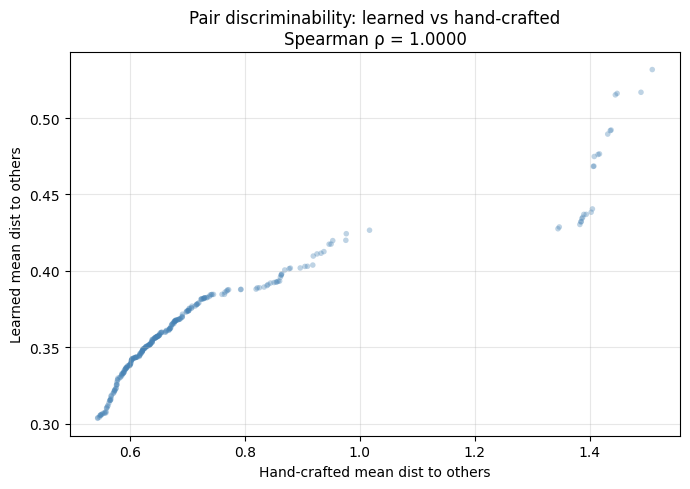

In [27]:
def rank_pairs_by_discriminability(table):
    """table: [24, 24, D] → list of (mean_dist, (i,j)) sorted ascending."""
    vecs = np.array([table[i, j] for i, j in pairs])       # [276, D]
    diff = vecs[:, None, :] - vecs[None, :, :]              # [276, 276, D]
    dmat = np.linalg.norm(diff, axis=-1)                    # [276, 276]
    np.fill_diagonal(dmat, 0.0)
    mean_d = dmat.sum(axis=1) / (len(pairs) - 1)
    return sorted(zip(mean_d, pairs), key=lambda x: x[0])

ranked_L  = rank_pairs_by_discriminability(table_L_mean)
ranked_hc = rank_pairs_by_discriminability(table_mean_normalized)

TOP_N = 10

def fmt(ranked, label):
    print(f'\n{label}')
    print(f'  {"Pair":<40}  mean dist')
    print('  ' + '-' * 52)
    print('  MOST discriminative:')
    for d, (i, j) in reversed(ranked[-TOP_N:]):
        print(f'    ({JOINT_NAMES[i]}, {JOINT_NAMES[j]}){" "*(36-len(JOINT_NAMES[i])-len(JOINT_NAMES[j]))}  {d:.5f}')
    print('  LEAST discriminative:')
    for d, (i, j) in ranked[:TOP_N]:
        print(f'    ({JOINT_NAMES[i]}, {JOINT_NAMES[j]}){" "*(36-len(JOINT_NAMES[i])-len(JOINT_NAMES[j]))}  {d:.5f}')

fmt(ranked_L,  'Learned embeddings (64-D)')
fmt(ranked_hc, 'Hand-crafted features (6-D normalized)')

# agreement: how many of the top-10 most discriminative pairs appear in both?
top_L  = {(i, j) for _, (i, j) in ranked_L[-TOP_N:]}
top_hc = {(i, j) for _, (i, j) in ranked_hc[-TOP_N:]}
bot_L  = {(i, j) for _, (i, j) in ranked_L[:TOP_N]}
bot_hc = {(i, j) for _, (i, j) in ranked_hc[:TOP_N]}
print(f'\nAgreement on top-{TOP_N} most discriminative  : {len(top_L & top_hc)}/{TOP_N} pairs in common')
print(f'Agreement on top-{TOP_N} least discriminative : {len(bot_L & bot_hc)}/{TOP_N} pairs in common')

# scatter: discriminability rank correlation (Spearman)
from scipy.stats import spearmanr
dist_L  = np.array([d for d, _ in ranked_L])
dist_hc = np.array([d for d, _ in ranked_hc])
rho, pval = spearmanr(dist_L, dist_hc)
print(f'\nSpearman rank correlation (all 276 pairs): ρ = {rho:.4f}  p = {pval:.2e}')
print('(ρ close to 1.0 means both approaches agree on which pairs are easy/hard to distinguish)')

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(dist_hc, dist_L, alpha=0.35, s=16, color='steelblue', edgecolors='none')
ax.set_xlabel('Hand-crafted mean dist to others')
ax.set_ylabel('Learned mean dist to others')
ax.set_title(f'Pair discriminability: learned vs hand-crafted\nSpearman ρ = {rho:.4f}')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()